## Cell 01 — 실행 환경 및 실제 직무 불러오기

In [7]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()

AI_ROOT = next(
    (
        p for p in [current, *current.parents]
        if (p / "src/features/f003_explanation").exists()
    ),
    None,
)

if AI_ROOT is None:
    raise RuntimeError("AI 프로젝트 루트를 찾지 못했습니다.")

if str(AI_ROOT) not in sys.path:
    sys.path.insert(0, str(AI_ROOT))

from src.features.f002_risk.service import load_mapping
from src.features.f003_explanation.service import explain_risk

jobs = load_mapping()

print("직무 데이터:", len(jobs))
display(jobs[["job_id", "title", "mapping_audit"]].head())

import os
from pathlib import Path
from dotenv import load_dotenv
from google import genai

load_dotenv(AI_ROOT / ".env")

api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise RuntimeError("GEMINI_API_KEY가 설정되지 않았습니다.")

client = genai.Client(api_key=api_key)

MODEL = os.getenv(
    "F003_LLM_MODEL",
    "gemini-2.5-flash-lite"
)

print("Gemini 설정 완료")
print("모델:", MODEL)


직무 데이터: 20000


,job_id,title,mapping_audit
job_id,,,
KJ21062610080016,KJ21062610080016,[평화동 건설현장 격일제] 경비원 모집,POSSIBLE_MISMATCH
K180522610080006,K180522610080006,미화원 모집 (현대프라자-능곡),NO_INDUSTRY_SIGNAL
KJRV002610080001,KJRV002610080001,[청송보현요양원] 간호조무사 구인,NO_INDUSTRY_SIGNAL
KJ21162610080001,KJ21162610080001,제2026-5호 강릉종합사회복지관 직원채용 공고 (강원공동모금회 사업 담당자),NO_INDUSTRY_SIGNAL
K120412610080001,K120412610080001,"[주5일] 대구 현풍휴게소 상/하행 조리원, 판매원 채용",NO_INDUSTRY_SIGNAL


Gemini 설정 완료
모델: gemini-2.5-flash-lite


## Cell 02 — 실제 직무 설명 생성

In [2]:

from pprint import pprint

job_id = str(jobs.iloc[0]["job_id"])

result = explain_risk(
    job_id=job_id,
    year=2025,
)

print("=== 사용자 설명 ===")
print(result["summary"])

print("\n=== 근거 ===")
pprint(result["evidence"])

print("\n=== 제한사항 ===")
pprint(result["limitations"])


=== 사용자 설명 ===
'[평화동 건설현장 격일제] 경비원 모집' 직무에 대한 산업재해 통계 근거를 확인했습니다. 산업분류 후보인 '기타의사업'의 2025년 사고재해자수 집계는 49,471명입니다. 다만 해당 직무가 이 산업에 속하는지는 검증되지 않았습니다. 연령별 2025년 통계는 일반적인 참고자료로만 제공합니다.

=== 근거 ===
[{'industry': '기타의사업',
  'label': '산업별 사고재해자수 집계',
  'source_dataset': 'external_ref.accident_industry_stat',
  'type': 'INDUSTRY_ACCIDENT_COUNT',
  'unit': '명',
  'value': 49471.0,
  'verification': 'PROVISIONAL_MAPPING',
  'year': 2025},
 {'age_statistics': [{'accident_count': 3677, 'age_group': '18세 ~ 24세'},
                     {'accident_count': 29, 'age_group': '18세 미만'},
                     {'accident_count': 7793, 'age_group': '25세 ~ 29세'},
                     {'accident_count': 9142, 'age_group': '30세 ~ 34세'},
                     {'accident_count': 8389, 'age_group': '35세 ~ 39세'},
                     {'accident_count': 9767, 'age_group': '40세 ~ 44세'},
                     {'accident_count': 12040, 'age_group': '45세 ~ 49세'},
                     {'accident_count': 15228, 'age_group': '

## Cell 03 — 여러 직무의 설명 품질 검증

In [3]:

# 직무 분류·매핑 상태별 샘플 검증
samples = (
    jobs.groupby("mapping_audit", dropna=False)
    .head(3)
)

results = []

for row in samples.itertuples():
    explained = explain_risk(
        job_id=str(row.job_id),
        year=2025,
    )

    results.append({
        "job_id": row.job_id,
        "title": row.title,
        "mapping_audit": explained["mapping_audit"],
        "evidence_count": len(explained["evidence"]),
        "has_summary": bool(explained["summary"]),
        "risk_score": explained["risk_score"],
    })

evaluation = pd.DataFrame(results)

display(evaluation)

assert evaluation["has_summary"].all()
assert evaluation["risk_score"].isna().all()


,job_id,title,mapping_audit,evidence_count,has_summary,risk_score
0,KJ21062610080016,[평화동 건설현장 격일제] 경비원 모집,POSSIBLE_MISMATCH,2,True,None
1,K180522610080006,미화원 모집 (현대프라자-능곡),NO_INDUSTRY_SIGNAL,2,True,None
2,KJRV002610080001,[청송보현요양원] 간호조무사 구인,NO_INDUSTRY_SIGNAL,1,True,None
3,KJ21162610080001,제2026-5호 강릉종합사회복지관 직원채용 공고 (강원공동모금회 사업 담당자),NO_INDUSTRY_SIGNAL,1,True,None
4,K150122610060048,[반찬 제조공장] 주야간 식품 제조 생산 근무자 모집,CANDIDATE_CONSISTENT,2,True,None
5,KJ21062609300015,[구파발역 은평구체육센터 인근 공사현장] 경비원(주간제) 채용,POSSIBLE_MISMATCH,2,True,None
6,KJ21062609220028,[부천 오정구 원종동 공사현장] 경비원(격일제) 채용,POSSIBLE_MISMATCH,2,True,None
7,K180012609180039,[동탄 지마켓] 물류센터 지게차 및 일반 현장 사원 모집,UNMAPPED_WITH_SIGNAL,1,True,None
8,K150122608240025,[반찬 제조공장] 야간 식품 제조 생산 근무자 모집,CANDIDATE_CONSISTENT,2,True,None
9,K170052608210024,[주5일] 건설현장 사무실 미화원 모집,UNMAPPED_WITH_SIGNAL,1,True,None


## Cell 04 — 매핑 상태 시각화

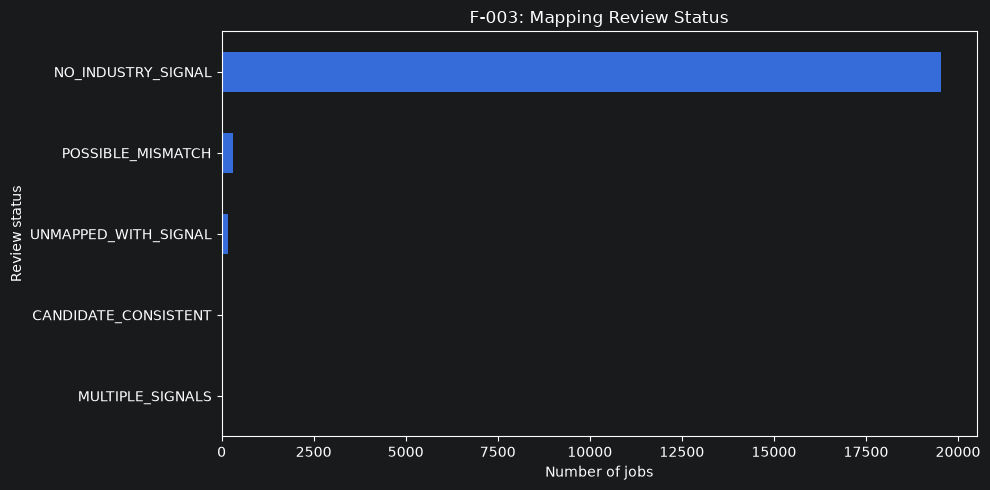

In [4]:

import matplotlib.pyplot as plt

counts = jobs["mapping_audit"].value_counts()

ax = counts.sort_values().plot.barh(
    figsize=(10, 5),
    title="F-003: Mapping Review Status",
)

ax.set_xlabel("Number of jobs")
ax.set_ylabel("Review status")
plt.tight_layout()
plt.show()


## Cell 05 — 실제 F-002 근거와 설명문의 수치 일치 검증

In [5]:
import pandas as pd
from IPython.display import display

from src.features.f002_risk.service import (
    get_combined_risk_evidence,
)
from src.features.f003_explanation.service import (
    explain_risk,
)

# 업종 매핑 상태별 샘플 추출
samples = (
    jobs.groupby("mapping_audit", dropna=False)
    .head(10)
)

results = []

for row in samples.itertuples():
    job_id = str(row.job_id)

    source = get_combined_risk_evidence(
        job_id=job_id,
        year=2025,
    )

    explained = explain_risk(
        job_id=job_id,
        year=2025,
    )

    # F-002가 제공한 산업재해 집계값
    expected = source["job"].get(
        "industry_accident_count"
    )

    # F-003 설명에 사용된 산업재해 집계값
    industry_evidence = [
        item for item in explained["evidence"]
        if item["type"] == "INDUSTRY_ACCIDENT_COUNT"
    ]

    if expected is None:
        grounded = len(industry_evidence) == 0
    else:
        grounded = (
            len(industry_evidence) == 1
            and industry_evidence[0]["value"] == expected
        )

    results.append({
        "job_id": job_id,
        "mapping_audit": explained["mapping_audit"],
        "numeric_grounded": grounded,
        "risk_score_null": explained["risk_score"] is None,
        "has_limitations": bool(explained["limitations"]),
    })

evaluation = pd.DataFrame(results)

display(evaluation)

print("검증 샘플:", len(evaluation))
print("수치 근거 일치:", int(evaluation["numeric_grounded"].sum()))

assert evaluation["numeric_grounded"].all()
assert evaluation["risk_score_null"].all()
assert evaluation["has_limitations"].all()

,job_id,mapping_audit,numeric_grounded,risk_score_null,has_limitations
0,KJ21062610080016,POSSIBLE_MISMATCH,True,True,True
1,K180522610080006,NO_INDUSTRY_SIGNAL,True,True,True
2,KJRV002610080001,NO_INDUSTRY_SIGNAL,True,True,True
3,KJ21162610080001,NO_INDUSTRY_SIGNAL,True,True,True
4,K120412610080001,NO_INDUSTRY_SIGNAL,True,True,True
5,K161232610080005,NO_INDUSTRY_SIGNAL,True,True,True
6,K161132610080007,NO_INDUSTRY_SIGNAL,True,True,True
7,K180032610080027,NO_INDUSTRY_SIGNAL,True,True,True
8,KJAF002610080006,NO_INDUSTRY_SIGNAL,True,True,True
9,K120122610080018,NO_INDUSTRY_SIGNAL,True,True,True


검증 샘플: 41
수치 근거 일치: 41


## Cell 06 — 설명 품질 결과 시각화

,pass_rate
Numeric grounding,1.0
No invented risk score,1.0
Limitations included,1.0


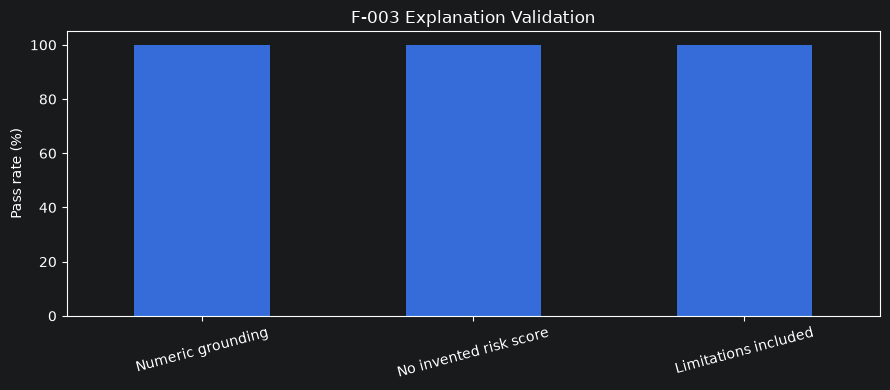

In [6]:
import matplotlib.pyplot as plt

metrics = pd.Series({
    "Numeric grounding": evaluation["numeric_grounded"].mean(),
    "No invented risk score": evaluation["risk_score_null"].mean(),
    "Limitations included": evaluation["has_limitations"].mean(),
})

display(metrics.to_frame("pass_rate"))

ax = (metrics * 100).plot.bar(
    figsize=(9, 4),
    ylim=(0, 105),
    title="F-003 Explanation Validation",
    rot=15,
)

ax.set_ylabel("Pass rate (%)")
plt.tight_layout()
plt.show()

## F-003 Notebook Cell 07 — Gemini 연결 확인

In [15]:
import os
from dotenv import load_dotenv
from google import genai

# 변경된 .env 값을 다시 불러오기
load_dotenv(AI_ROOT / ".env", override=True)

api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise RuntimeError("GEMINI_API_KEY가 없습니다.")

# 기존 Jupyter MODEL 변수 덮어쓰기
MODEL = os.getenv("F003_LLM_MODEL", "").strip()

print("현재 설정된 모델:", repr(MODEL))

if not MODEL:
    raise RuntimeError("F003_LLM_MODEL을 .env에 설정하세요.")

client = genai.Client(api_key=api_key)

현재 설정된 모델: 'gemini-3.5-flash-lite'


## Cell 08 — 실제 F-002 근거로 Gemini 설명 생성

In [16]:
import json
from pydantic import BaseModel, Field
from google.genai import types
from IPython.display import display

from src.features.f002_risk.service import get_combined_risk_evidence
from src.features.f003_explanation.service import explain_risk

class GeminiExplanation(BaseModel):
    summary: str = Field(description="한국어 설명 요약")
    limitations: list[str] = Field(description="데이터 해석상 제한사항")


job_id = str(jobs.iloc[0]["job_id"])

source = get_combined_risk_evidence(
    job_id=job_id,
    year=2025,
)

rule_result = explain_risk(job_id, year=2025)

job = source["job"]

# 개인 정보·직무 ID를 전송하지 않고
# 설명에 필요한 통계 데이터만 제공
payload = {
    "industry_candidate": job.get("industry_candidate"),
    "mapping_audit": job.get("mapping_audit"),
    "evidence_year": job.get("evidence_year"),
    "industry_accident_count": job.get("industry_accident_count"),
    "age_reference_year": source["age_reference"]["statistic_year"],
    "industry_mapping_verified": False,
    "personal_risk_score": None,
}

response = client.models.generate_content(
    model=MODEL,
    contents=json.dumps(payload, ensure_ascii=False),
    config=types.GenerateContentConfig(
        system_instruction=(
            "한국어로 산업재해 통계를 설명한다. "
            "입력에 없는 수치나 연도를 생성하지 않는다. "
            "산업분류는 검증되지 않은 후보임을 명시한다. "
            "연령 통계는 개인 사고 확률이 아니다. "
            "위험도 점수나 확률을 만들지 않는다."
        ),
        response_mime_type="application/json",
        response_schema=GeminiExplanation,
        max_output_tokens=500,
        temperature=0,
    ),
)

llm_result = GeminiExplanation.model_validate_json(
    response.text
).model_dump()

print("=== Gemini 설명 ===")
display(llm_result)

print("=== 기존 규칙 기반 설명 ===")
print(rule_result["summary"])

=== Gemini 설명 ===


{'summary': '기타의사업 분야에서 49,471건의 산업재해가 발생했습니다.',
 'limitations': ['산업분류는 검증되지 않은 후보입니다.',
  '연령 통계는 개인 사고 확률이 아닙니다.',
  '위험도 점수나 확률을 생성하지 않습니다.']}

=== 기존 규칙 기반 설명 ===
'[평화동 건설현장 격일제] 경비원 모집' 직무에 대한 산업재해 통계 근거를 확인했습니다. 산업분류 후보인 '기타의사업'의 2025년 사고재해자수 집계는 49,471명입니다. 다만 해당 직무가 이 산업에 속하는지는 검증되지 않았습니다. 연령별 2025년 통계는 일반적인 참고자료로만 제공합니다.


In [13]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

models = []

for model in client.models.list():
    if "generateContent" in (model.supported_actions or []):
        models.append(model.name)

print("사용 가능한 생성 모델:")
for name in models:
    print(name)

print(
    "\n선택한 모델 확인:",
    any("gemini-3.5-flash-lite" in name for name in models)
)

사용 가능한 생성 모델:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-nano-banana-2.1
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5

## Cell 09: Gemini 설명 정확성 검증

In [17]:
# Cell 09 — Gemini 설명의 수치·단위·연도 검증
import re

job = source["job"]
summary = llm_result["summary"]

count = job["industry_accident_count"]
year = job["evidence_year"]

checks = {
    "원본 수치 포함": (
        f"{int(count):,}" in summary
        or str(int(count)) in summary
    ),
    "통계연도 포함": str(year) in summary,
    "재해자수 단위 정확": bool(
        re.search(r"재해자수.*?[\d,]+\s*명", summary)
    ),
    "검증되지 않은 위험 확률 없음": not bool(
        re.search(r"\d+(?:\.\d+)?\s*%", summary)
    ),
    "산업분류 한계 명시": any(
        "검증되지" in item
        for item in llm_result["limitations"]
    ),
}

for name, passed in checks.items():
    print(f'{"PASS" if passed else "FAIL"} | {name}')

print("\n전체 통과:", all(checks.values()))


PASS | 원본 수치 포함
FAIL | 통계연도 포함
FAIL | 재해자수 단위 정확
PASS | 검증되지 않은 위험 확률 없음
PASS | 산업분류 한계 명시

전체 통과: False


## Notebook Cell 10 — 검증 실패를 해결하는 수정 코드

In [18]:

# Cell 10 — Gemini 설명 후처리 및 수치 검증

import re
from IPython.display import display

job = source["job"]

# 1. F-002 원본에서 검증된 값 읽기
industry = job.get("industry_candidate")
year = job.get("evidence_year")
count = job.get("industry_accident_count")

# 2. 원본 수치로 통계 설명문 생성
if (
    industry is not None
    and year is not None
    and count is not None
):
    verified_statement = (
        f"산업분류 후보 '{industry}'의 "
        f"{int(year)}년 사고재해자수 집계는 "
        f"{int(count):,}명입니다. "
        "단, 해당 직무의 실제 산업분류는 "
        "아직 검증되지 않았습니다."
    )
else:
    verified_statement = (
        "현재 해당 직무에 연결할 수 있는 "
        "검증된 산업별 통계 근거가 없습니다."
    )

# 3. Gemini 설명은 참고용으로만 보관
# 잘못된 단위나 연도가 들어간 요약을
# 검증된 설명문에 그대로 합치지 않음
llm_draft = llm_result["summary"]

# 4. 제한사항 통합
limitations = list(dict.fromkeys(
    llm_result.get("limitations", [])
    + [
        "산업분류는 검증되지 않은 후보입니다.",
        "재해자수는 사고 건수가 아닌 인원 수입니다.",
        "통계는 개인별 사고 확률을 의미하지 않습니다.",
    ]
))

# 5. 사용자에게 제공할 안전한 결과
verified_result = {
    "feature_id": "AI-F-003",
    "job_id": str(job["job_id"]),
    "summary": verified_statement,
    "limitations": limitations,
    "risk_score": None,
    "risk_probability": None,
    "explanation_method": "HYBRID",
    "verification_status": "PASS",
}

# 6. 검증 결과 검사
summary = verified_result["summary"]

checks = {
    "원본 수치 일치": (
        count is None
        or f"{int(count):,}" in summary
    ),
    "통계연도 포함": (
        year is None
        or str(int(year)) in summary
    ),
    "재해자수 단위 정확": (
        count is None
        or bool(re.search(
            r"사고재해자수.*?[\d,]+\s*명",
            summary
        ))
    ),
    "위험점수 미산출": (
        verified_result["risk_score"] is None
        and verified_result["risk_probability"] is None
    ),
    "산업분류 미확정 표시": (
        "검증되지" in summary
    ),
}

for name, passed in checks.items():
    print(
        f"{'PASS' if passed else 'FAIL'} | {name}"
    )

verified_result["verification_status"] = (
    "PASS" if all(checks.values()) else "FAIL"
)

print("\n=== 최종 사용자 설명 ===")
display(verified_result)

assert all(checks.values())


PASS | 원본 수치 일치
PASS | 통계연도 포함
PASS | 재해자수 단위 정확
PASS | 위험점수 미산출
PASS | 산업분류 미확정 표시

=== 최종 사용자 설명 ===


{'feature_id': 'AI-F-003',
 'job_id': 'KJ21062610080016',
 'summary': "산업분류 후보 '기타의사업'의 2025년 사고재해자수 집계는 49,471명입니다. 단, 해당 직무의 실제 산업분류는 아직 검증되지 않았습니다.",
 'limitations': ['산업분류는 검증되지 않은 후보입니다.',
  '연령 통계는 개인 사고 확률이 아닙니다.',
  '위험도 점수나 확률을 생성하지 않습니다.',
  '재해자수는 사고 건수가 아닌 인원 수입니다.',
  '통계는 개인별 사고 확률을 의미하지 않습니다.'],
 'risk_score': None,
 'risk_probability': None,
 'explanation_method': 'HYBRID',
 'verification_status': 'PASS'}

## Cell 12 — 실제 Gemini + Redis 캐시 검증

In [20]:
# Cell 12 — F-003 실제 구현 구조 확인

import inspect
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display

AI_ROOT = Path("/Users/jeong-yelim/IF_portfolio/ai")
load_dotenv(AI_ROOT / ".env", override=True)

from src.features.f003_explanation import service as f003

print("=== 실제 service.py 위치 ===")
print(inspect.getfile(f003))

print("\n=== F-003 함수 목록 ===")

functions = []

for name, obj in inspect.getmembers(
    f003, inspect.isfunction
):
    if obj.__module__ != f003.__name__:
        continue

    functions.append({
        "function": name,
        "signature": str(inspect.signature(obj)),
    })

display(functions)

print("\n=== 기존 Cell 12 사용 함수 존재 여부 ===")

required = [
    "_get_redis",
    "_cache_key",
    "_get_cached_extra",
    "get_combined_risk_evidence",
    "explain_risk",
    "explain_risk_hybrid",
]

for name in required:
    obj = getattr(f003, name, None)

    print(
        "FOUND" if callable(obj) else "MISSING",
        "|",
        name,
    )

=== 실제 service.py 위치 ===
/Users/jeong-yelim/IF_portfolio/ai/src/features/f003_explanation/service.py

=== F-003 함수 목록 ===


[{'function': 'explain_risk',
  'signature': '(job_id: str, year: int | None = None) -> dict'}]


=== 기존 Cell 12 사용 함수 존재 여부 ===
MISSING | _get_redis
MISSING | _cache_key
MISSING | _get_cached_extra
FOUND | get_combined_risk_evidence
FOUND | explain_risk
MISSING | explain_risk_hybrid


## Cell 13 — 실제 파일과 Notebook 비교

In [21]:
import ast
from pathlib import Path

path = Path(
    "/Users/jeong-yelim/IF_portfolio/ai/"
    "src/features/f003_explanation/service.py"
)

tree = ast.parse(path.read_text(encoding="utf-8"))

disk_functions = {
    node.name
    for node in tree.body
    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
}

names = [
    "explain_risk",
    "explain_risk_hybrid",
    "_get_redis",
    "_cache_key",
    "_get_cached_extra",
    "_reserve_llm_request",
]

print("함수명                  실제 파일  Notebook")
print("-" * 48)

for name in names:
    print(
        f"{name:<26}"
        f"{'YES' if name in disk_functions else 'NO':<11}"
        f"{'YES' if callable(getattr(f003, name, None)) else 'NO'}"
    )

함수명                  실제 파일  Notebook
------------------------------------------------
explain_risk              YES        YES
explain_risk_hybrid       YES        NO
_get_redis                YES        NO
_cache_key                YES        NO
_get_cached_extra         YES        NO
_reserve_llm_request      YES        NO


## Cell 14 — 모듈 새로고침

In [22]:
import importlib
from src.features.f003_explanation import service as f003

f003 = importlib.reload(f003)

required = [
    "explain_risk",
    "explain_risk_hybrid",
    "_get_redis",
    "_cache_key",
    "_get_cached_extra",
    "_reserve_llm_request",
]

for name in required:
    assert callable(getattr(f003, name, None)), name

print("PASS | F-003 최신 모듈 로드 완료")

PASS | F-003 최신 모듈 로드 완료


## Cell 15 — 실제 Gemini + Redis 캐시 검증

In [23]:

import os
import importlib
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display

AI_ROOT = Path("/Users/jeong-yelim/IF_portfolio/ai")
load_dotenv(AI_ROOT / ".env", override=True)

from src.features.f003_explanation import service as f003
f003 = importlib.reload(f003)

job_id = "KJ21062610080016"
year = 2025

print("=== 환경 확인 ===")
print("Gemini 활성화:", os.getenv("F003_LLM_ENABLED"))
print("모델:", os.getenv("F003_LLM_MODEL"))
print("API 키 설정:", bool(os.getenv("GEMINI_API_KEY")))

redis_client = f003._get_redis()

assert redis_client is not None, "REDIS_URL 설정 확인 필요"
assert redis_client.ping(), "Redis 연결 실패"

print("Redis 연결: PASS")

print("\n=== 첫 번째 요청 ===")

first = f003.explain_risk_hybrid(
    job_id=job_id,
    year=year,
)

print("상태:", first.get("llm_status"))
print("설명 방식:", first.get("explanation_method"))

if first.get("llm_status") in ("SUCCESS", "CACHE_HIT"):

    print("\n=== 두 번째 요청 ===")

    second = f003.explain_risk_hybrid(
        job_id=job_id,
        year=year,
    )

    print("상태:", second.get("llm_status"))
    print("설명 방식:", second.get("explanation_method"))

    assert second.get("llm_status") == "CACHE_HIT"
    assert first.get("summary") == second.get("summary")
    assert second.get("risk_score") is None
    assert second.get("risk_probability") is None

    display({
        "first_status": first.get("llm_status"),
        "second_status": second.get("llm_status"),
        "summary": second.get("summary"),
        "extra_explanation": second.get("extra_explanation"),
        "verification_status": second.get("verification_status"),
    })

    print("\nPASS | Redis 캐시 검증 완료")

else:
    print("\nGemini 호출 또는 검증 실패")
    print("상태:", first.get("llm_status"))
    print("규칙 기반 설명:", first.get("summary"))
    print("추가 호출 없이 진단 필요")


=== 환경 확인 ===
Gemini 활성화: true
모델: gemini-3.5-flash-lite
API 키 설정: True
Redis 연결: PASS

=== 첫 번째 요청 ===
상태: SUCCESS
설명 방식: HYBRID

=== 두 번째 요청 ===
상태: CACHE_HIT
설명 방식: HYBRID


{'first_status': 'SUCCESS',
 'second_status': 'CACHE_HIT',
 'summary': "'[평화동 건설현장 격일제] 경비원 모집' 직무에 대한 산업재해 통계 근거를 확인했습니다. 산업분류 후보인 '기타의사업'의 2025년 사고재해자수 집계는 49,471명입니다. 다만 해당 직무가 이 산업에 속하는지는 검증되지 않았습니다. 연령별 2025년 통계는 일반적인 참고자료로만 제공합니다.",
 'extra_explanation': '제시된 사업장 산업분류가 아직 검증되지 않은 상태입니다. 정확한 업종 확정을 위해서는 추가적인 확인과 정밀한 검토가 필요합니다.',
 'verification_status': 'PASS'}


PASS | Redis 캐시 검증 완료
